In [2]:
%matplotlib inline

!pip install pydicom
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.9 MB/s eta 0:00:00


# DICOM exploration

I'm going to look at the CT image and segmentations for NLST patient 100012

In [3]:
# First, let's visualize the CT file itself
ct_file = os.path.join('nlst', '100012',
    '1.2.840.113654.2.55.238034941445508011386463276954045956831',
    'CT_1.2.840.113654.2.55.240231128564881525363489796879328810792',
    '3b2619b5-f026-48c7-9306-72d4910d9090.dcm'
)

# Load the file
with open(ct_file, 'rb') as f:
    ct = pydicom.dcmread(f)

# Plot the pixel data
fig, ax = plt.subplots(1, 1, dpi=200)
ax.imshow(ct.pixel_array, cmap='Grays_r')

# Format axis
ax.set(xticks=[], yticks=[])

FileNotFoundError: [Errno 2] No such file or directory: 'nlst/100012/1.2.840.113654.2.55.238034941445508011386463276954045956831/CT_1.2.840.113654.2.55.240231128564881525363489796879328810792/3b2619b5-f026-48c7-9306-72d4910d9090.dcm'

The CT file contains metadata, which looks like this

In [ ]:
ct

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 192
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113654.2.55.217964292073602949448233866411576229843
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.31'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM5 SPI']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.840.113654.2.55.217964292073602949448233866411576229843
(0008,0020) Study Date              

This metadata allows us to connect the SEG file to the CT file. First, let's collect all the slices of the full CT volume

In [ ]:
from pathlib import Path

ct_folder = Path(ct_file).parent.absolute()
SOP_files = {}  # Keep a reference from the SOP Instance UID to the corresponding file
SERIES_INSTANCE_UID = None # For checking the dicom series

for dcm_file in ct_folder.glob('*.dcm'):
    with open(dcm_file, 'rb') as f:
        ct = pydicom.dcmread(f)

    if SERIES_INSTANCE_UID is None:
        SERIES_INSTANCE_UID = ct.SeriesInstanceUID
    elif ct.SeriesInstanceUID != SERIES_INSTANCE_UID:
        continue # Only keep track of the first series we see

    SOP_files[ct.SOPInstanceUID] = dcm_file

Next, let's try to find the SEG files that reference the CT file. We can do this by looking at the Referenced Series Instance UID, which is a metadata field in each SEG DICOM file. Rather than do this by hand, I can just loop over all of the DCM files and do metadata inspection.

In [ ]:
# Find the matching SEG file(s)
SEG_files = []
for root, directory, files in os.walk('nlst/100012/1.2.840.113654.2.55.3832109283939010833855886500020760484'):
    for file in files:
        if not file.endswith('dcm'):
            continue

        with open(os.path.join(root, file), 'rb') as f:
            dcm = pydicom.dcmread(f)

        # Check that it's a segmentation file
        if dcm.Modality != 'SEG':
            continue

        # Check that it references the current CT series
        if dcm.ReferencedSeriesSequence[0].SeriesInstanceUID == SERIES_INSTANCE_UID:
            print(f'Found match in {os.path.join(root, file)}')
            SEG_files.append(os.path.join(root, file))


print(f'Found {len(SEG_files)} matches')

Found match in nlst/100012/1.2.840.113654.2.55.3832109283939010833855886500020760484\SEG_1.2.276.0.7230010.3.1.3.17436516.3063738.1720665129.785873\c0449ece-7770-471d-9431-00998144414c.dcm
Found match in nlst/100012/1.2.840.113654.2.55.3832109283939010833855886500020760484\SEG_1.2.276.0.7230010.3.1.3.313263360.30440.1706323110.782377\81e0b8f8-fd33-4222-8c40-7054d8f3fc6c.dcm
Found 2 matches


Interesting, there are two SEG files that appear to match. Let's see what's in each of them

In [ ]:
with open(SEG_files[0], 'rb') as f:
    seg = pydicom.dcmread(f)

for segment in seg.SegmentSequence:
    print(segment.SegmentLabel)

Spleen
Left Kidney
Gallbladder
Liver
Stomach
Aorta
Inferior vena cava
Portal vein and splenic vein
Pancreas
Right Adrenal gland
Left Adrenal gland
Left Upper lobe of lung
Left Lower lobe of lung
Right Upper lobe of lung
Middle lobe of right lung
Right Lower lobe of lung
L1 vertebra
T12 vertebra
T11 vertebra
T10 vertebra
T9 vertebra
T8 vertebra
T7 vertebra
T6 vertebra
T5 vertebra
T4 vertebra
T3 vertebra
T2 vertebra
T1 vertebra
C7 vertebra
C6 vertebra
Esophagus
Trachea
Myocardium
Left atrium
Left ventricle of heart
Right atrium
Right ventricle of heart
Pulmonary artery
Colon
Left First rib
Left Second rib
Left Third rib
Left Fourth rib
Left Fifth rib
Left Sixth rib
Left Seventh rib
Left Eighth rib
Left Ninth rib
Left Tenth rib
Left Eleventh rib
Left Twelfth rib
Right First rib
Right Second rib
Right Third rib
Right Fourth rib
Right Fifth rib
Right Sixth rib
Right Seventh rib
Right Eighth rib
Right Ninth rib
Right Tenth rib
Right Eleventh rib
Right Twelfth rib
Left Humerus
Right Humerus
L

In [ ]:
with open(SEG_files[1], 'rb') as f:
    seg = pydicom.dcmread(f)

for segment in seg.SegmentSequence:
    print(segment.SegmentLabel)

Lung
Nodule


The first SEG file contains standard anatomical contours, which is nice. The second one has the nodule. Let's try to visualze the nodule in one of the CT slices.

The SEG file has a pixel_array field that is of shape [N, H, W]. N corresponds to the number of contour slices, while H, W are the image size.
First, we need to go through the segmentation metadata. Among other things, the PerFrameFunctionalGroupsSequence field tells me two things about each element of the pixel_array:

1. Which CT slice it corresponds to
2. Which segmentation it corresponds to

If we want to visualize the lung nodule, let's first figure out which CT slices contain both the Lung and Nodule contour, and pick a random one of those

In [ ]:
SOP_frame_indices = {} # Track which frame segments are in each CT slice
for ii, frame_segment in enumerate(seg.PerFrameFunctionalGroupsSequence):
    referenced_SOP = frame_segment.DerivationImageSequence[0].SourceImageSequence[0].ReferencedSOPInstanceUID
    if referenced_SOP not in SOP_files.keys(): # Double check we're not referring to a non-existent file
        continue
    if referenced_SOP not in SOP_frame_indices: # Create a list for each SOP Instance UID
        SOP_frame_indices[referenced_SOP] = []

    if seg.pixel_array[ii].sum() == 0: # Don't include this frame segment if it has no non-zero elements
        continue

    SOP_frame_indices[referenced_SOP].append(ii) # Track that this segment appears over a specific CT slice

# Randomly select a frame to visualize that has at least two segments
SOP_instance_to_visualize = np.random.choice([key for key, value in SOP_frame_indices.items() if len(value) == 2])
print(SOP_instance_to_visualize, SOP_frame_indices[SOP_instance_to_visualize])

1.2.840.113654.2.55.273962229454169102884420877690060620637 [131, 236]


Now we can visualize it by overlaying the segmentation masks against the CT, see below

[[], []]

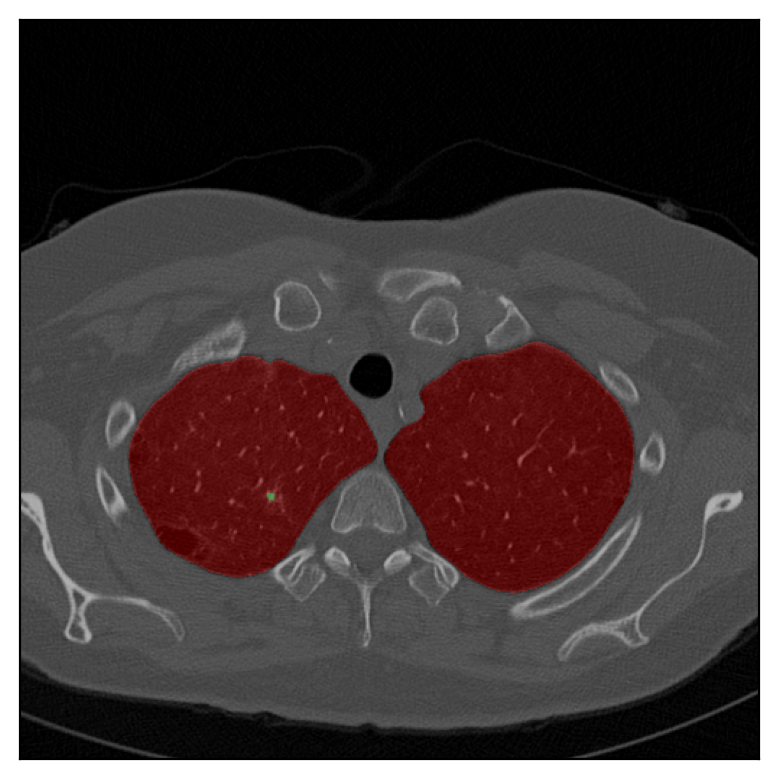

In [ ]:
fig, ax = plt.subplots(1, 1, dpi=200)

# Plot the CT slice
with open(SOP_files[SOP_instance_to_visualize], 'rb') as f:
    ct = pydicom.dcmread(f)

ax.imshow(ct.pixel_array, cmap='Grays_r')

# Use different RGB channels to represent different contours
mask = np.zeros([*ct.pixel_array.shape, 3])
for ii, ind in enumerate(SOP_frame_indices[SOP_instance_to_visualize]):
    mask[:, :, ii] = seg.pixel_array[ind, :, :]

# Plot the mask. I DON'T KNOW why the segmentations appear inverted relative to the CT
# This also occurs in Weasis Viewer and Fiji, although the online IDC viewer works fine?
ax.imshow(mask[::-1], alpha=0.3)

# Format axis
ax.set(xticks=[], yticks=[])

Finally, this is what the SEG file metadata looks like. It's long, so I suggest putting it in a text editor or something to read

In [ ]:
seg

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 204
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Segmentation Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.17436516.3063738.1720665129.785874
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.6
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_366'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0016) SOP Class UID                       UI: Segmentation Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.17436516.3063738.1720665129.785874
(0008,0020) Study Date                      